<a href="https://colab.research.google.com/github/soultanyousif/Cross-Domain-Few-Shot-Classification-with-Visual-Prompting/blob/main/Cross_Domain_Few_Shot_Classification_with_Visual_Prompting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross-Domain Few-Shot Classification with Visual Prompting
- CLIP ViT-B/16: Linear Probe | VPT-Shallow | VPT-Deep |
- Full Fine-Tune
- Datasets: EuroSAT, DTD, Flowers102

In [ ]:
import copy
import os
import random
import time
import warnings
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Subset
from transformers import CLIPModel

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    _props = torch.cuda.get_device_properties(0)
    print(f"  {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {_props.total_memory / 1e9:.1f} GB")

Device: cuda
  Tesla T4
  VRAM: 15.6 GB


In [ ]:
# Backbone
CLIP_MODEL  = "openai/clip-vit-base-patch16"
IMAGE_SIZE  = 224
PATCH_SIZE  = 16
N_PATCHES   = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 196
HIDDEN_DIM  = 768                               # ViT-B/16 hidden size
N_LAYERS    = 12                                # ViT-B/16 depth

# VPT defaults (overridden during ablation)
DEFAULT_PROMPT_TOKENS = 16
PROMPT_DROPOUT        = 0.1

#  Per-method training schedule
EPOCHS_VPT      = 50
EPOCHS_FINETUNE = 80      # more epochs compensate for the lower LR
LR_VPT          = 1e-3
LR_LINEAR       = 1e-3
LR_FINETUNE     = 1e-5    # 100x lower than VPT; prevents forgetting
WD              = 1e-4
BATCH_SIZE      = 64

#  Experiment scope
SHOT_COUNTS = [1, 2, 4, 8, 16]
DATASETS    = ["eurosat", "dtd", "flowers102"]
METHODS     = ["linear_probe", "vpt_shallow", "vpt_deep", "full_finetune"]
VPT_METHODS = ["vpt_shallow", "vpt_deep"]

#  Phase 1 ablation grid
ABLATION_DATASET        = "eurosat"
ABLATION_PROMPT_LENGTHS = [1, 4, 8, 16, 32, 64]

# Display
METHOD_LABELS: Dict[str, str] = {
    "linear_probe":  "Linear Probe",
    "vpt_shallow":   "VPT-Shallow",
    "vpt_deep":      "VPT-Deep",
    "full_finetune": "Full Fine-Tune",
}
COLORS: Dict[str, str] = {
    "linear_probe":  "#B4B2A9",
    "vpt_shallow":   "#7F77DD",
    "vpt_deep":      "#1D9E75",
    "full_finetune": "#D85A30",
}

print(
    f"Phase 1 runs : {len(VPT_METHODS)} x {len(SHOT_COUNTS)} x "
    f"{len(ABLATION_PROMPT_LENGTHS)} = "
    f"{len(VPT_METHODS)*len(SHOT_COUNTS)*len(ABLATION_PROMPT_LENGTHS)}"
)
print(
    f"Phase 2 runs : {len(DATASETS)} x {len(SHOT_COUNTS)} x "
    f"{len(METHODS)} = "
    f"{len(DATASETS)*len(SHOT_COUNTS)*len(METHODS)}"
)

Phase 1 runs : 2 x 5 x 6 = 60
Phase 2 runs : 3 x 5 x 4 = 60


In [ ]:
CLIP_MEAN = [0.48145466, 0.4578275,  0.40821073]
CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]

TRAIN_TF = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=CLIP_MEAN, std=CLIP_STD),
])
VAL_TF = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=CLIP_MEAN, std=CLIP_STD),
])


class HFDataset(torch.utils.data.Dataset):
    """Wraps a HuggingFace split into a PyTorch-compatible Dataset."""

    def __init__(
        self,
        hf_split,
        label_col: str = "label",
        transform: Optional[T.Compose] = None,
    ) -> None:
        self.data      = hf_split
        self.label_col = label_col
        self.transform = transform

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        item = self.data[idx]
        img  = item["image"].convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, item[self.label_col]


def few_shot_subset(
    dataset: torch.utils.data.Dataset,
    n_shots: int,
    seed: int = SEED,
) -> Subset:
    """
    Return a stratified Subset with exactly n_shots examples per class.

    If a class has fewer than n_shots samples the entire class is used.
    """
    rng     = np.random.RandomState(seed)
    labels  = np.array([dataset[i][1] for i in range(len(dataset))])
    classes = np.unique(labels)
    indices: List[int] = []
    for c in classes:
        c_idx  = np.where(labels == c)[0]
        chosen = rng.choice(c_idx, min(n_shots, len(c_idx)), replace=False)
        indices.extend(chosen.tolist())
    return Subset(dataset, indices)


def load_hf_dataset(
    name: str,
) -> Tuple[
    torch.utils.data.Dataset,
    torch.utils.data.Dataset,
    int,
    List[str],
]:
    """
    Load train/val splits and class names for a benchmark dataset.

    Parameters
    ----------
    name : "eurosat" | "dtd" | "flowers102"

    Returns
    -------
    train_dataset, val_dataset, n_classes, class_names
    """
    print(f"Loading {name}...")
    if name == "eurosat":
        ds    = load_dataset("timm/eurosat-rgb")
        train = HFDataset(ds["train"], transform=TRAIN_TF)
        val   = HFDataset(
            ds["validation"] if "validation" in ds else ds["test"],
            transform=VAL_TF,
        )
        n_cls       = 10
        class_names = ds["train"].features["label"].names

    elif name == "dtd":
        ds    = load_dataset("tanganke/dtd")
        train = HFDataset(ds["train"], transform=TRAIN_TF)
        val   = HFDataset(ds["test"],  transform=VAL_TF)
        n_cls       = 47
        class_names = ds["train"].features["label"].names

    elif name == "flowers102":
        import torchvision.datasets as tvd

        os.makedirs("/tmp/flowers", exist_ok=True)
        tv_train = tvd.Flowers102(
            root="/tmp/flowers", split="train",
            transform=TRAIN_TF, download=True,
        )
        tv_val = tvd.Flowers102(
            root="/tmp/flowers", split="test",
            transform=VAL_TF, download=True,
        )

        class TVWrapper(torch.utils.data.Dataset):
            def __init__(self, ds: torch.utils.data.Dataset) -> None:
                self.ds = ds
            def __len__(self) -> int:
                return len(self.ds)
            def __getitem__(self, i: int) -> Tuple[torch.Tensor, int]:
                return self.ds[i]

        train       = TVWrapper(tv_train)
        val         = TVWrapper(tv_val)
        n_cls       = 102
        class_names = [str(i) for i in range(102)]

    else:
        raise ValueError(f"Unknown dataset: {name}")

    print(f"  -> {len(train)} train | {len(val)} val | {n_cls} classes")
    return train, val, n_cls, class_names


# Pre-load all datasets into memory before training starts
DATASET_CACHE: Dict[str, Tuple] = {}
for _ds_name in DATASETS:
    DATASET_CACHE[_ds_name] = load_hf_dataset(_ds_name)
print("loaded")

Loading eurosat...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/55.3M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/18.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/18.4M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1880 [00:00<?, ? examples/s]

  -> 3760 train | 1880 val | 47 classes
Loading flowers102...


100%|██████████| 345M/345M [00:09<00:00, 35.8MB/s] 
100%|██████████| 502/502 [00:00<00:00, 2.72MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 24.9MB/s]

  -> 1020 train | 6149 val | 102 classes
loaded


In [ ]:
_clip       = CLIPModel.from_pretrained(CLIP_MODEL)
CLIP_VISION = _clip.vision_model
del _clip

CLIP_VISION.eval()
CLIP_VISION = CLIP_VISION.to(DEVICE)
for p in CLIP_VISION.parameters():
    p.requires_grad_(False)

_total_clip = sum(p.numel() for p in CLIP_VISION.parameters())
print(f"CLIP ViT params: {_total_clip:,} (all frozen for VPT / linear probe)")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

CLIP ViT params: 85,799,424 (all frozen for VPT / linear probe)


In [ ]:
def _get_clip_components(
    clip_vision: nn.Module,
) -> Tuple[nn.Module, nn.ModuleList, nn.Module, nn.Module]:
    """Extract the four reusable building blocks from the CLIP vision model."""
    emb    = clip_vision.embeddings
    layers = clip_vision.encoder.layers
    try:
        pre_ln = clip_vision.pre_layrnorm    # older transformers
    except AttributeError:
        pre_ln = clip_vision.pre_layernorm
    post_ln = clip_vision.post_layernorm
    return emb, layers, pre_ln, post_ln


def _forward_layer(
    layer: nn.Module,
    hidden_states: torch.Tensor,
) -> torch.Tensor:
    """
    Run one transformer encoder layer.

    Handles all three output conventions that CLIP layers may return:
    raw tensor, tuple, or ModelOutput.
    """
    out = layer(
        hidden_states,
        attention_mask=None,
        causal_attention_mask=None,
        output_attentions=False,
    )
    if isinstance(out, torch.Tensor):
        return out
    if isinstance(out, tuple):
        return out[0]
    return out.last_hidden_state


def _run_layers(
    layers: nn.ModuleList,
    hidden_states: torch.Tensor,
    n_prompts: int = 0,
    prompts_list: Optional[nn.ParameterList] = None,
    dropout: Optional[nn.Dropout] = None,
    mode: str = "none",
) -> torch.Tensor:
    """
    Forward pass through all transformer layers with optional prompt injection.

    Parameters
    ----------
    mode : "none"    -- no prompts (linear probe / full fine-tune path)
           "shallow" -- inject prompts at layer 0 only
           "deep"    -- inject fresh prompts at every layer
    """
    B = hidden_states.shape[0]
    for i, layer in enumerate(layers):
        inject = mode == "deep" or (mode == "shallow" and i == 0)
        if inject:
            p = prompts_list[i] if mode == "deep" else prompts_list[0]
            p = dropout(p.expand(B, -1, -1))
            # Insert after CLS token, before patch tokens
            hidden_states = torch.cat(
                [hidden_states[:, :1, :], p, hidden_states[:, 1:, :]],
                dim=1,
            )

        hidden_states = _forward_layer(layer, hidden_states)

        if inject:
            # Strip the prompt tokens before the next layer
            hidden_states = torch.cat(
                [
                    hidden_states[:, :1, :],
                    hidden_states[:, 1 + n_prompts:, :],
                ],
                dim=1,
            )
    return hidden_states


class LinearProbe(nn.Module):
    """
    Frozen CLIP backbone with a single learnable linear classifier.

    Trainable parameters: classification head only.
    This is the lowest-parameter baseline.
    """

    def __init__(self, clip_vision: nn.Module, n_classes: int) -> None:
        super().__init__()
        self.clip_vision = clip_vision
        self.head        = nn.Linear(HIDDEN_DIM, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            out = self.clip_vision(pixel_values=x)
        cls_feat = out.last_hidden_state[:, 0, :]
        return self.head(cls_feat)

    def trainable_params(self) -> List[nn.Parameter]:
        return list(self.head.parameters())


class VPTShallow(nn.Module):
    """
    VPT-Shallow: learnable prompt tokens prepended at layer 0 only.

    The same prompt set is injected once; all backbone weights stay frozen.
    Trainable parameters: one prompt tensor of shape (1, n_prompts, 768)
    plus the classification head.
    """

    def __init__(
        self,
        clip_vision: nn.Module,
        n_classes: int,
        n_prompts: int = DEFAULT_PROMPT_TOKENS,
    ) -> None:
        super().__init__()
        self.n_prompts = n_prompts
        emb, layers, pre_ln, post_ln = _get_clip_components(clip_vision)
        self.emb     = copy.deepcopy(emb);     self.emb.requires_grad_(False)
        self.layers  = copy.deepcopy(layers);  self.layers.requires_grad_(False)
        self.pre_ln  = copy.deepcopy(pre_ln);  self.pre_ln.requires_grad_(False)
        self.post_ln = copy.deepcopy(post_ln); self.post_ln.requires_grad_(False)
        self.prompts = nn.ParameterList([
            nn.Parameter(
                torch.zeros(1, n_prompts, HIDDEN_DIM).normal_(std=0.02)
            )
        ])
        self.dropout = nn.Dropout(PROMPT_DROPOUT)
        self.head    = nn.Linear(HIDDEN_DIM, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            h = self.emb(x)
            h = self.pre_ln(h)
        h = _run_layers(
            self.layers, h,
            n_prompts=self.n_prompts,
            prompts_list=self.prompts,
            dropout=self.dropout,
            mode="shallow",
        )
        return self.head(self.post_ln(h[:, 0, :]))

    def trainable_params(self) -> List[nn.Parameter]:
        return list(self.prompts.parameters()) + list(self.head.parameters())


class VPTDeep(nn.Module):
    """
    VPT-Deep: a separate set of learnable prompt tokens is injected at
    every transformer layer.

    Trainable parameters: N_LAYERS prompt tensors, each of shape
    (1, n_prompts, 768), plus the classification head.
    """

    def __init__(
        self,
        clip_vision: nn.Module,
        n_classes: int,
        n_prompts: int = DEFAULT_PROMPT_TOKENS,
    ) -> None:
        super().__init__()
        self.n_prompts = n_prompts
        emb, layers, pre_ln, post_ln = _get_clip_components(clip_vision)
        self.emb     = copy.deepcopy(emb);     self.emb.requires_grad_(False)
        self.layers  = copy.deepcopy(layers);  self.layers.requires_grad_(False)
        self.pre_ln  = copy.deepcopy(pre_ln);  self.pre_ln.requires_grad_(False)
        self.post_ln = copy.deepcopy(post_ln); self.post_ln.requires_grad_(False)
        n_l = len(layers)
        self.prompts = nn.ParameterList([
            nn.Parameter(
                torch.zeros(1, n_prompts, HIDDEN_DIM).normal_(std=0.02)
            )
            for _ in range(n_l)
        ])
        self.dropout = nn.Dropout(PROMPT_DROPOUT)
        self.head    = nn.Linear(HIDDEN_DIM, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            h = self.emb(x)
            h = self.pre_ln(h)
        h = _run_layers(
            self.layers, h,
            n_prompts=self.n_prompts,
            prompts_list=self.prompts,
            dropout=self.dropout,
            mode="deep",
        )
        return self.head(self.post_ln(h[:, 0, :]))

    def trainable_params(self) -> List[nn.Parameter]:
        return list(self.prompts.parameters()) + list(self.head.parameters())


class FullFineTune(nn.Module):
    """
    Full fine-tuning: every backbone parameter and the classification
    head are updated.

    Use a much lower LR (LR_FINETUNE = 1e-5) to avoid catastrophic
    forgetting on tiny few-shot support sets.
    """

    def __init__(self, clip_vision: nn.Module, n_classes: int) -> None:
        super().__init__()
        self.clip_vision = copy.deepcopy(clip_vision)
        for p in self.clip_vision.parameters():
            p.requires_grad_(True)
        self.head = nn.Linear(HIDDEN_DIM, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.clip_vision(pixel_values=x)
        return self.head(out.last_hidden_state[:, 0, :])

    def trainable_params(self) -> List[nn.Parameter]:
        return list(self.parameters())


def build_model(
    method: str,
    n_classes: int,
    n_prompts: int = DEFAULT_PROMPT_TOKENS,
) -> nn.Module:
    """Instantiate the requested model and move it to DEVICE."""
    if method == "linear_probe":
        return LinearProbe(CLIP_VISION, n_classes).to(DEVICE)
    if method == "vpt_shallow":
        return VPTShallow(CLIP_VISION, n_classes, n_prompts=n_prompts).to(DEVICE)
    if method == "vpt_deep":
        return VPTDeep(CLIP_VISION, n_classes, n_prompts=n_prompts).to(DEVICE)
    if method == "full_finetune":
        return FullFineTune(CLIP_VISION, n_classes).to(DEVICE)
    raise ValueError(f"Unknown method: {method}")


def count_trainable(model: nn.Module) -> int:
    """Return the number of trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Forward-pass sanity check
print("\nTrainable parameter counts (EuroSAT, 10 classes):")
_dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
for _m in METHODS:
    _mdl = build_model(_m, 10)
    with torch.no_grad():
        _out = _mdl(_dummy)
    assert _out.shape == (2, 10), f"Bad shape for {_m}: {_out.shape}"
    print(f"  {_m:<20}: {count_trainable(_mdl):>12,} params  output={tuple(_out.shape)}")
    del _mdl
torch.cuda.empty_cache()
print("d ")


Trainable parameter counts (EuroSAT, 10 classes):
  linear_probe        :        7,690 params  output=(2, 10)
  vpt_shallow         :       19,978 params  output=(2, 10)
  vpt_deep            :      155,146 params  output=(2, 10)
  full_finetune       :   85,807,114 params  output=(2, 10)
d 


In [ ]:
def get_lr_and_epochs(method: str) -> Tuple[float, int]:
    """Return (learning_rate, n_epochs) for a given method."""
    if method == "full_finetune":
        return LR_FINETUNE, EPOCHS_FINETUNE
    if method == "linear_probe":
        return LR_LINEAR, EPOCHS_VPT
    return LR_VPT, EPOCHS_VPT


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scaler: torch.cuda.amp.GradScaler,
) -> Tuple[float, float]:
    """
    Run one epoch of mixed-precision training.

    Returns
    -------
    mean_loss, train_accuracy
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model(imgs)
            loss   = F.cross_entropy(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> float:
    """Return top-1 accuracy (0.0 to 1.0) on a DataLoader."""
    model.eval()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast():
            logits = model(imgs)
        correct += (logits.argmax(1) == labels).sum().item()
        total   += imgs.size(0)
    return correct / total


@torch.no_grad()
def evaluate_with_predictions(
    model: nn.Module,
    loader: DataLoader,
) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    Full evaluation pass that also returns raw predictions.

    Returns
    -------
    accuracy, predictions (N,), true_labels (N,)
    """
    model.eval()
    all_preds:  List[int] = []
    all_labels: List[int] = []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast():
            logits = model(imgs)
        all_preds.extend(logits.argmax(1).cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    return float((preds == labels).mean()), preds, labels


def run_experiment(
    method: str,
    n_classes: int,
    train_full: torch.utils.data.Dataset,
    val_full: torch.utils.data.Dataset,
    n_shots: int,
    n_prompts: int = DEFAULT_PROMPT_TOKENS,
) -> Tuple[float, int]:
    """
    Build, train, and evaluate one (method, shot, prompt_length) cell.

    Returns
    -------
    best_val_accuracy (0.0 to 1.0), trainable_param_count
    """
    model    = build_model(method, n_classes, n_prompts=n_prompts)
    n_params = count_trainable(model)
    lr, epochs = get_lr_and_epochs(method)

    train_sub = few_shot_subset(train_full, n_shots)
    train_ldr = DataLoader(
        train_sub,
        batch_size=min(BATCH_SIZE, len(train_sub)),
        shuffle=True, num_workers=2, pin_memory=True,
    )
    val_ldr = DataLoader(
        val_full, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True
    )

    optimizer = torch.optim.AdamW(
        model.trainable_params(), lr=lr, weight_decay=WD
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )
    scaler   = torch.cuda.amp.GradScaler()
    best_acc = 0.0

    for epoch in range(epochs):
        train_one_epoch(model, train_ldr, optimizer, scaler)
        scheduler.step()
        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            acc      = evaluate(model, val_ldr)
            best_acc = max(best_acc, acc)

    del model
    torch.cuda.empty_cache()
    return best_acc, n_params



print('d')

d


In [ ]:
print(
    f"PHASE 1: Shot x Prompt-Length Ablation "
    f"(dataset={ABLATION_DATASET.upper()})"
)

_t_abl, _val_abl, _n_cls_abl, _ = DATASET_CACHE[ABLATION_DATASET]
ablation_records: List[Dict] = []
_total_abl = len(VPT_METHODS) * len(SHOT_COUNTS) * len(ABLATION_PROMPT_LENGTHS)
_run_idx   = 0
_t_abl_start = time.time()

for method in VPT_METHODS:
    for n_shots in SHOT_COUNTS:
        for pl in ABLATION_PROMPT_LENGTHS:
            _run_idx += 1
            _label = (
                f"[{_run_idx:>3}/{_total_abl}] "
                f"{method} | {n_shots:>2}-shot | prompt_len={pl:>3}"
            )
            print(f"{_label} ...", end=" ", flush=True)
            _t0 = time.time()

            acc, n_params = run_experiment(
                method, _n_cls_abl, _t_abl, _val_abl,
                n_shots=n_shots, n_prompts=pl,
            )
            _elapsed = time.time() - _t0
            ablation_records.append({
                "method":        method,
                "n_shots":       n_shots,
                "prompt_length": pl,
                "accuracy":      round(acc * 100, 2),
                "n_params":      n_params,
                "time_s":        round(_elapsed, 1),
            })
            print(f"acc={acc*100:.1f}%  ({_elapsed:.0f}s)")

abl_df = pd.DataFrame(ablation_records)
abl_df.to_csv("phase1_ablation.csv", index=False)
print(
    f"\nPhase 1 complete in "
    f"{(time.time() - _t_abl_start) / 60:.1f} min"
)
print(abl_df.to_string(index=False))

PHASE 1: Shot x Prompt-Length Ablation (dataset=EUROSAT)
[  1/60] vpt_shallow |  1-shot | prompt_len=  1 ... acc=55.9%  (146s)
[  2/60] vpt_shallow |  1-shot | prompt_len=  4 ... acc=46.8%  (151s)
[  3/60] vpt_shallow |  1-shot | prompt_len=  8 ... acc=48.5%  (152s)
[  4/60] vpt_shallow |  1-shot | prompt_len= 16 ... acc=47.3%  (153s)
[  5/60] vpt_shallow |  1-shot | prompt_len= 32 ... acc=48.3%  (153s)
[  6/60] vpt_shallow |  1-shot | prompt_len= 64 ... acc=50.1%  (154s)
[  7/60] vpt_shallow |  2-shot | prompt_len=  1 ... acc=65.1%  (158s)
[  8/60] vpt_shallow |  2-shot | prompt_len=  4 ... acc=65.6%  (157s)
[  9/60] vpt_shallow |  2-shot | prompt_len=  8 ... acc=68.9%  (157s)
[ 10/60] vpt_shallow |  2-shot | prompt_len= 16 ... acc=67.6%  (157s)
[ 11/60] vpt_shallow |  2-shot | prompt_len= 32 ... acc=66.3%  (159s)
[ 12/60] vpt_shallow |  2-shot | prompt_len= 64 ... acc=64.5%  (160s)
[ 13/60] vpt_shallow |  4-shot | prompt_len=  1 ... acc=77.4%  (170s)
[ 14/60] vpt_shallow |  4-shot | 

Best prompt length per (method, shots) on EUROSAT
  vpt_shallow     1-shot  -> prompt_length=  1  (acc=55.9%)
  vpt_shallow     2-shot  -> prompt_length=  8  (acc=68.9%)
  vpt_shallow     4-shot  -> prompt_length= 32  (acc=78.7%)
  vpt_shallow     8-shot  -> prompt_length= 32  (acc=82.3%)
  vpt_shallow    16-shot  -> prompt_length= 16  (acc=88.6%)
  vpt_deep        1-shot  -> prompt_length= 64  (acc=61.2%)
  vpt_deep        2-shot  -> prompt_length=  4  (acc=71.7%)
  vpt_deep        4-shot  -> prompt_length=  8  (acc=87.4%)
  vpt_deep        8-shot  -> prompt_length=  1  (acc=87.3%)
  vpt_deep       16-shot  -> prompt_length= 16  (acc=93.8%)


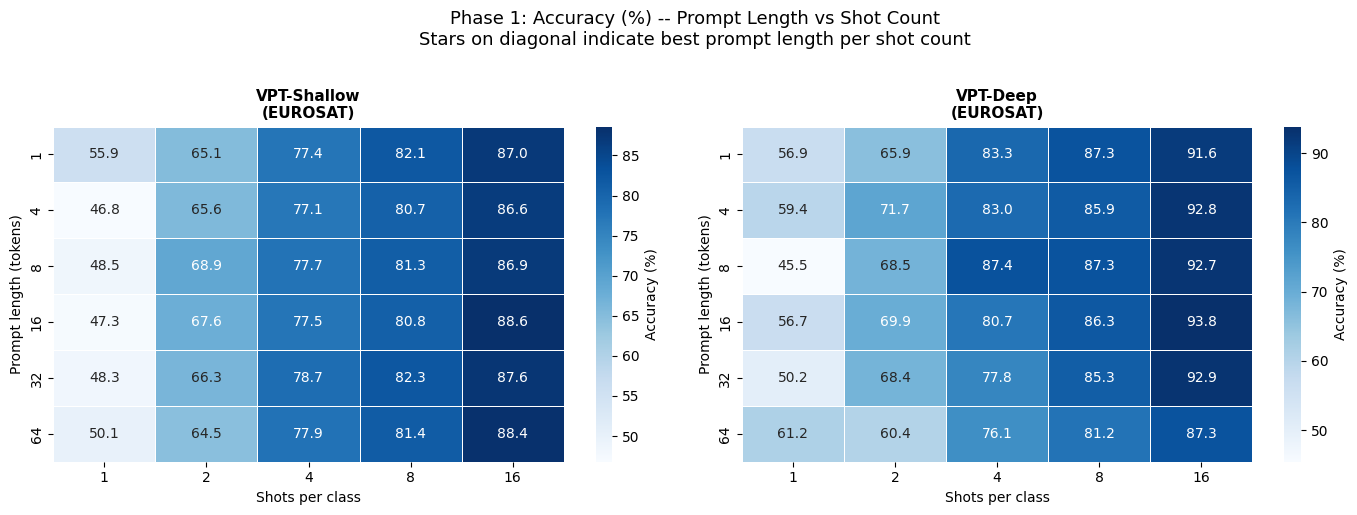

Saved phase1_prompt_length_heatmap.pdf


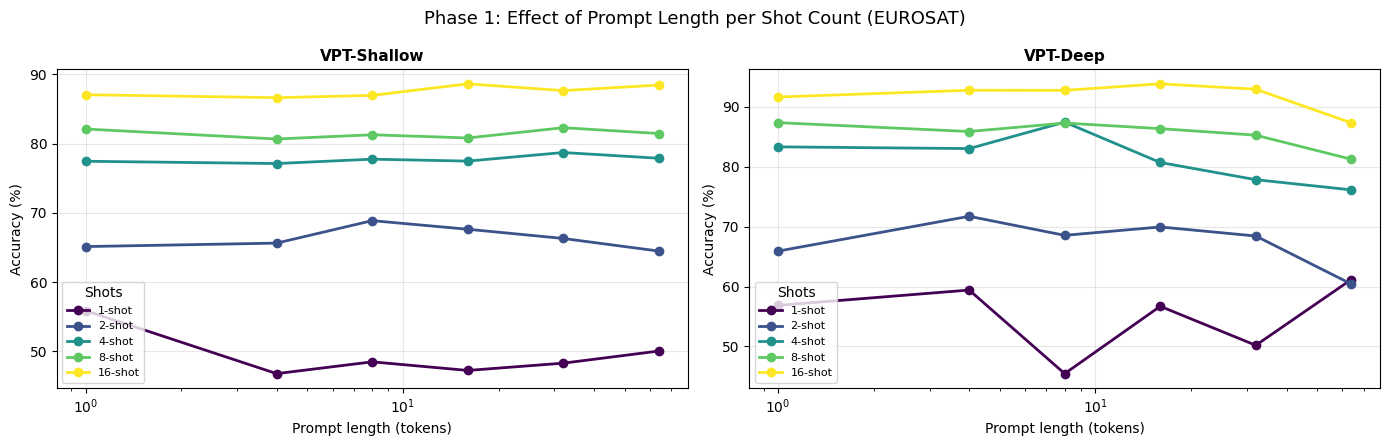

Saved phase1_prompt_length_curves.pdf


In [ ]:
best_prompt_config: Dict[Tuple[str, int], int] = {}

print(
    f"Best prompt length per (method, shots) on "
    f"{ABLATION_DATASET.upper()}"
)
for method in VPT_METHODS:
    for n_shots in SHOT_COUNTS:
        _sub     = abl_df[(abl_df.method == method) & (abl_df.n_shots == n_shots)]
        _best    = _sub.loc[_sub.accuracy.idxmax()]
        _best_pl = int(_best.prompt_length)
        best_prompt_config[(method, n_shots)] = _best_pl
        print(
            f"  {method:<14} {n_shots:>2}-shot  "
            f"-> prompt_length={_best_pl:>3}  "
            f"(acc={_best.accuracy:.1f}%)"
        )

#  Heatmap: accuracy over the (prompt_length, shots) grid
fig, axes = plt.subplots(1, len(VPT_METHODS), figsize=(14, 5))
for ax, method in zip(axes, VPT_METHODS):
    pivot = abl_df[abl_df.method == method].pivot(
        index="prompt_length", columns="n_shots", values="accuracy"
    )
    sns.heatmap(
        pivot, annot=True, fmt=".1f", cmap="Blues",
        linewidths=0.5, ax=ax,
        cbar_kws={"label": "Accuracy (%)"},
    )
    ax.set_title(
        f"{METHOD_LABELS[method]}\n({ABLATION_DATASET.upper()})",
        fontsize=11, fontweight="bold",
    )
    ax.set_xlabel("Shots per class", fontsize=10)
    ax.set_ylabel("Prompt length (tokens)", fontsize=10)

fig.suptitle(
    "Phase 1: Accuracy (%) -- Prompt Length vs Shot Count\n"
    "Stars on diagonal indicate best prompt length per shot count",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig("phase1_prompt_length_heatmap.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved phase1_prompt_length_heatmap.pdf")

#  Line plot: prompt-length curves coloured by shot count
fig, axes = plt.subplots(1, len(VPT_METHODS), figsize=(14, 4.5))
_shot_palette = plt.cm.get_cmap("viridis", len(SHOT_COUNTS))
for ax, method in zip(axes, VPT_METHODS):
    for idx, n_shots in enumerate(SHOT_COUNTS):
        _sub = abl_df[
            (abl_df.method == method) & (abl_df.n_shots == n_shots)
        ].sort_values("prompt_length")
        ax.plot(
            _sub.prompt_length, _sub.accuracy,
            marker="o", linewidth=2,
            color=_shot_palette(idx / len(SHOT_COUNTS)),
            label=f"{n_shots}-shot",
        )
    ax.set_title(METHOD_LABELS[method], fontsize=11, fontweight="bold")
    ax.set_xlabel("Prompt length (tokens)", fontsize=10)
    ax.set_ylabel("Accuracy (%)", fontsize=10)
    ax.legend(fontsize=8, title="Shots")
    ax.grid(True, alpha=0.3)
    ax.set_xscale("log")

fig.suptitle(
    f"Phase 1: Effect of Prompt Length per Shot Count "
    f"({ABLATION_DATASET.upper()})",
    fontsize=13,
)
plt.tight_layout()
plt.savefig("phase1_prompt_length_curves.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved phase1_prompt_length_curves.pdf")

In [ ]:
print(

    f"PHASE 2: Full Evaluation "
    f"({len(DATASETS)} datasets x {len(SHOT_COUNTS)} shots "
    f"x {len(METHODS)} methods)"
)

results: List[Dict] = []
param_counts: Dict[str, int] = {}

_total_p2   = len(DATASETS) * len(SHOT_COUNTS) * len(METHODS)
_run_idx    = 0
_t_p2_start = time.time()

for ds_name in DATASETS:
    _train_full, _val_full, _n_cls, _class_names = DATASET_CACHE[ds_name]
    for n_shots in SHOT_COUNTS:
        for method in METHODS:
            _run_idx += 1
            n_prompts = best_prompt_config.get(
                (method, n_shots), DEFAULT_PROMPT_TOKENS
            )
            _label = (
                f"[{_run_idx:>3}/{_total_p2}] "
                f"{ds_name:<12} | {n_shots:>2}-shot | {method}"
            )
            if method in VPT_METHODS:
                _label += f" (pl={n_prompts})"
            print(f"{_label} ...", end=" ", flush=True)
            _t0 = time.time()

            acc, n_params = run_experiment(
                method, _n_cls, _train_full, _val_full,
                n_shots=n_shots, n_prompts=n_prompts,
            )
            _elapsed = time.time() - _t0
            results.append({
                "dataset":       ds_name,
                "n_shots":       n_shots,
                "method":        method,
                "prompt_length": n_prompts,
                "accuracy":      round(acc * 100, 2),
                "n_params":      n_params,
                "time_s":        round(_elapsed, 1),
            })
            if method not in param_counts:
                param_counts[method] = n_params
            print(f"acc={acc*100:.1f}%  ({_elapsed:.0f}s)")

print(
    f"\nPhase 2 complete in "
    f"{(time.time() - _t_p2_start) / 60:.1f} min"
)

df = pd.DataFrame(results)
df.to_csv("phase2_results.csv", index=False)
print("Saved phase2_results.csv")
print(df.head(16).to_string(index=False))

PHASE 2: Full Evaluation (3 datasets x 5 shots x 4 methods)
[  1/60] eurosat      |  1-shot | linear_probe ... acc=50.2%  (147s)
[  2/60] eurosat      |  1-shot | vpt_shallow (pl=1) ... acc=53.5%  (150s)
[  3/60] eurosat      |  1-shot | vpt_deep (pl=64) ... acc=56.8%  (183s)
[  4/60] eurosat      |  1-shot | full_finetune ... acc=56.8%  (214s)
[  5/60] eurosat      |  2-shot | linear_probe ... acc=64.0%  (151s)
[  6/60] eurosat      |  2-shot | vpt_shallow (pl=8) ... acc=65.1%  (156s)
[  7/60] eurosat      |  2-shot | vpt_deep (pl=4) ... acc=68.1%  (163s)
[  8/60] eurosat      |  2-shot | full_finetune ... acc=70.6%  (224s)
[  9/60] eurosat      |  4-shot | linear_probe ... acc=73.7%  (158s)
[ 10/60] eurosat      |  4-shot | vpt_shallow (pl=32) ... acc=76.4%  (169s)
[ 11/60] eurosat      |  4-shot | vpt_deep (pl=8) ... acc=85.3%  (178s)
[ 12/60] eurosat      |  4-shot | full_finetune ... acc=85.8%  (247s)
[ 13/60] eurosat      |  8-shot | linear_probe ... acc=77.7%  (172s)
[ 14/60] eu

Detailed Metrics at 16-shot (per-class accuracy + confusion matrices)

EUROSAT | linear_probe | 16-shot
                      precision    recall  f1-score   support

          AnnualCrop       0.72      0.87      0.79       613
              Forest       0.83      0.74      0.79       605
HerbaceousVegetation       0.77      0.93      0.84       628
             Highway       0.82      0.76      0.79       499
          Industrial       0.93      0.88      0.90       507
             Pasture       0.79      0.72      0.76       409
       PermanentCrop       0.83      0.62      0.71       481
         Residential       0.87      0.93      0.90       583
               River       0.81      0.71      0.76       511
             SeaLake       0.81      0.89      0.85       564

            accuracy                           0.81      5400
           macro avg       0.82      0.81      0.81      5400
        weighted avg       0.82      0.81      0.81      5400


EUROSAT | vpt_shallow | 

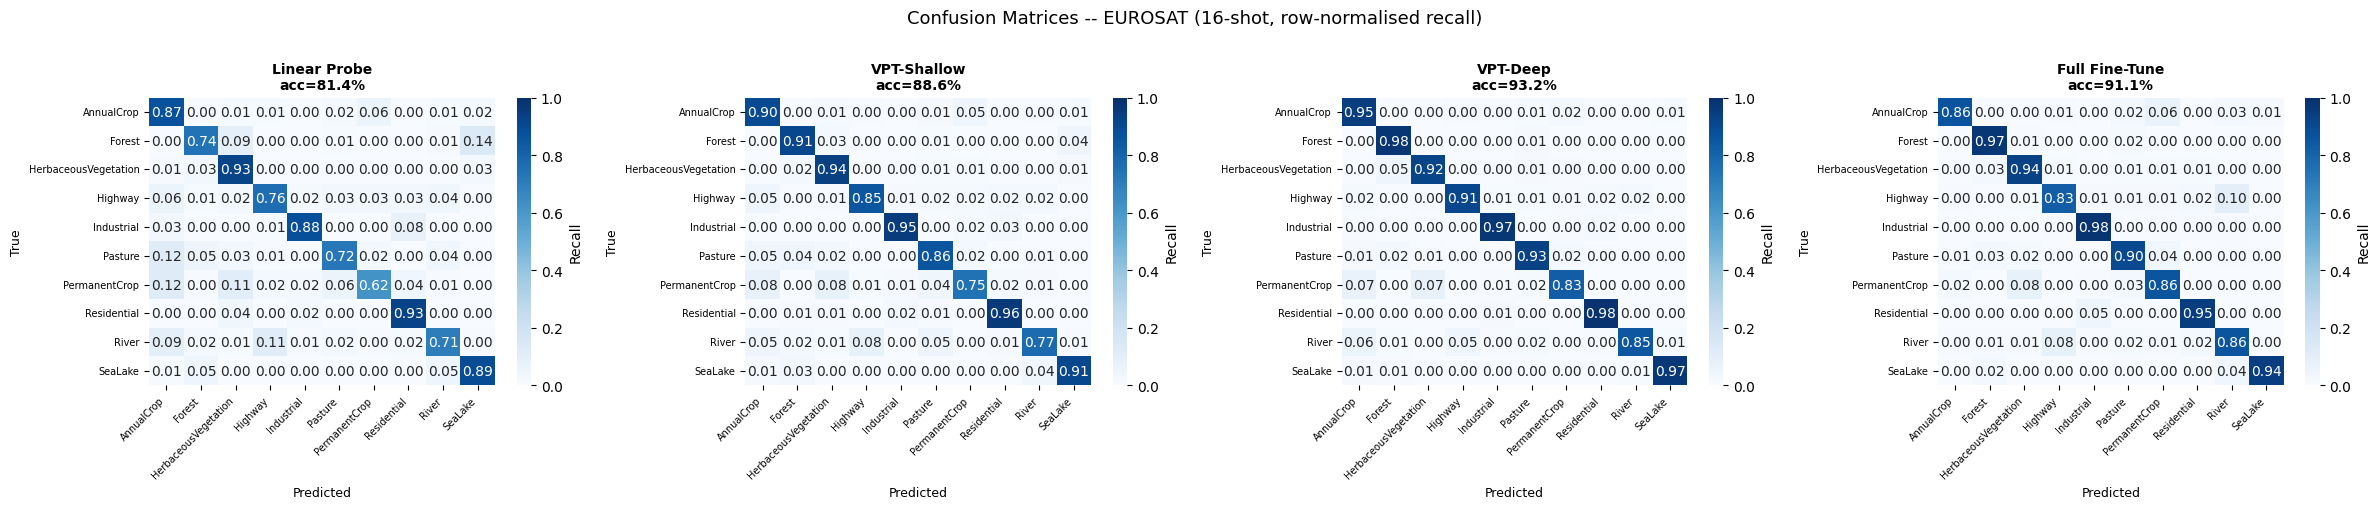

Saved confusion_matrix_eurosat_16shot.pdf

DTD | linear_probe | 16-shot
              precision    recall  f1-score   support

      banded       0.72      0.57      0.64        40
     blotchy       0.36      0.33      0.34        40
     braided       0.47      0.68      0.56        40
      bubbly       0.95      0.95      0.95        40
       bumpy       0.47      0.55      0.51        40
   chequered       0.95      0.90      0.92        40
   cobwebbed       0.97      0.93      0.95        40
     cracked       0.84      0.80      0.82        40
crosshatched       0.75      0.45      0.56        40
 crystalline       0.97      0.97      0.97        40
      dotted       0.59      0.75      0.66        40
     fibrous       0.70      0.70      0.70        40
     flecked       0.76      0.62      0.68        40
    freckled       0.87      0.68      0.76        40
      frilly       0.84      0.80      0.82        40
       gauzy       0.76      0.70      0.73        40
        g

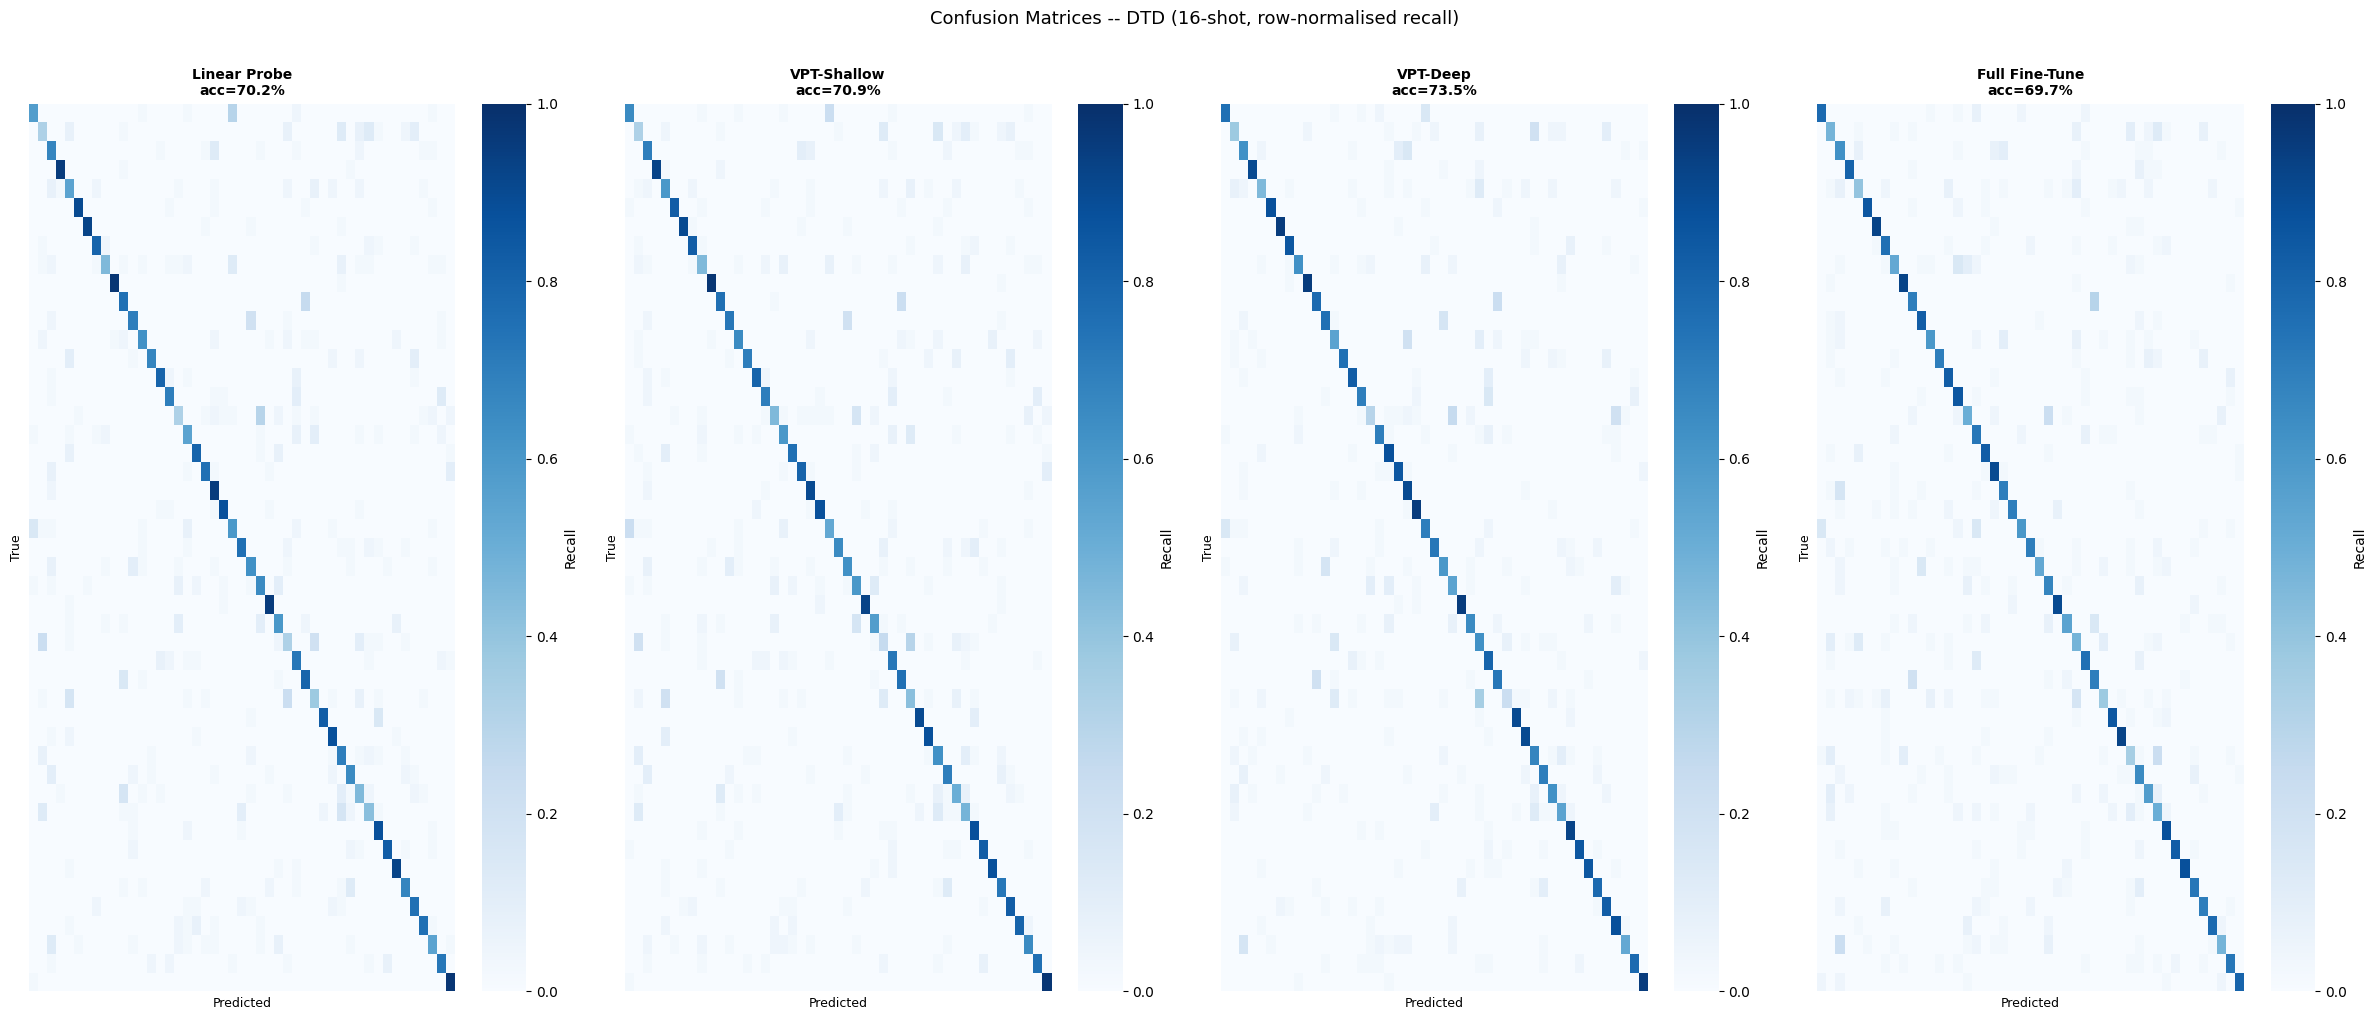

Saved confusion_matrix_dtd_16shot.pdf

FLOWERS102 | linear_probe | 16-shot
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        20
           1       0.97      0.97      0.97        40
           2       0.44      0.60      0.51        20
           3       1.00      0.69      0.82        36
           4       0.96      0.96      0.96        45
           5       1.00      1.00      1.00        25
           6       0.83      0.95      0.88        20
           7       1.00      1.00      1.00        65
           8       0.93      1.00      0.96        26
           9       0.92      0.92      0.92        25
          10       0.91      0.91      0.91        67
          11       0.92      0.97      0.94        67
          12       0.97      1.00      0.98        29
          13       0.97      1.00      0.98        28
          14       0.91      1.00      0.95        29
          15       0.91      0.95      0.93        21
      

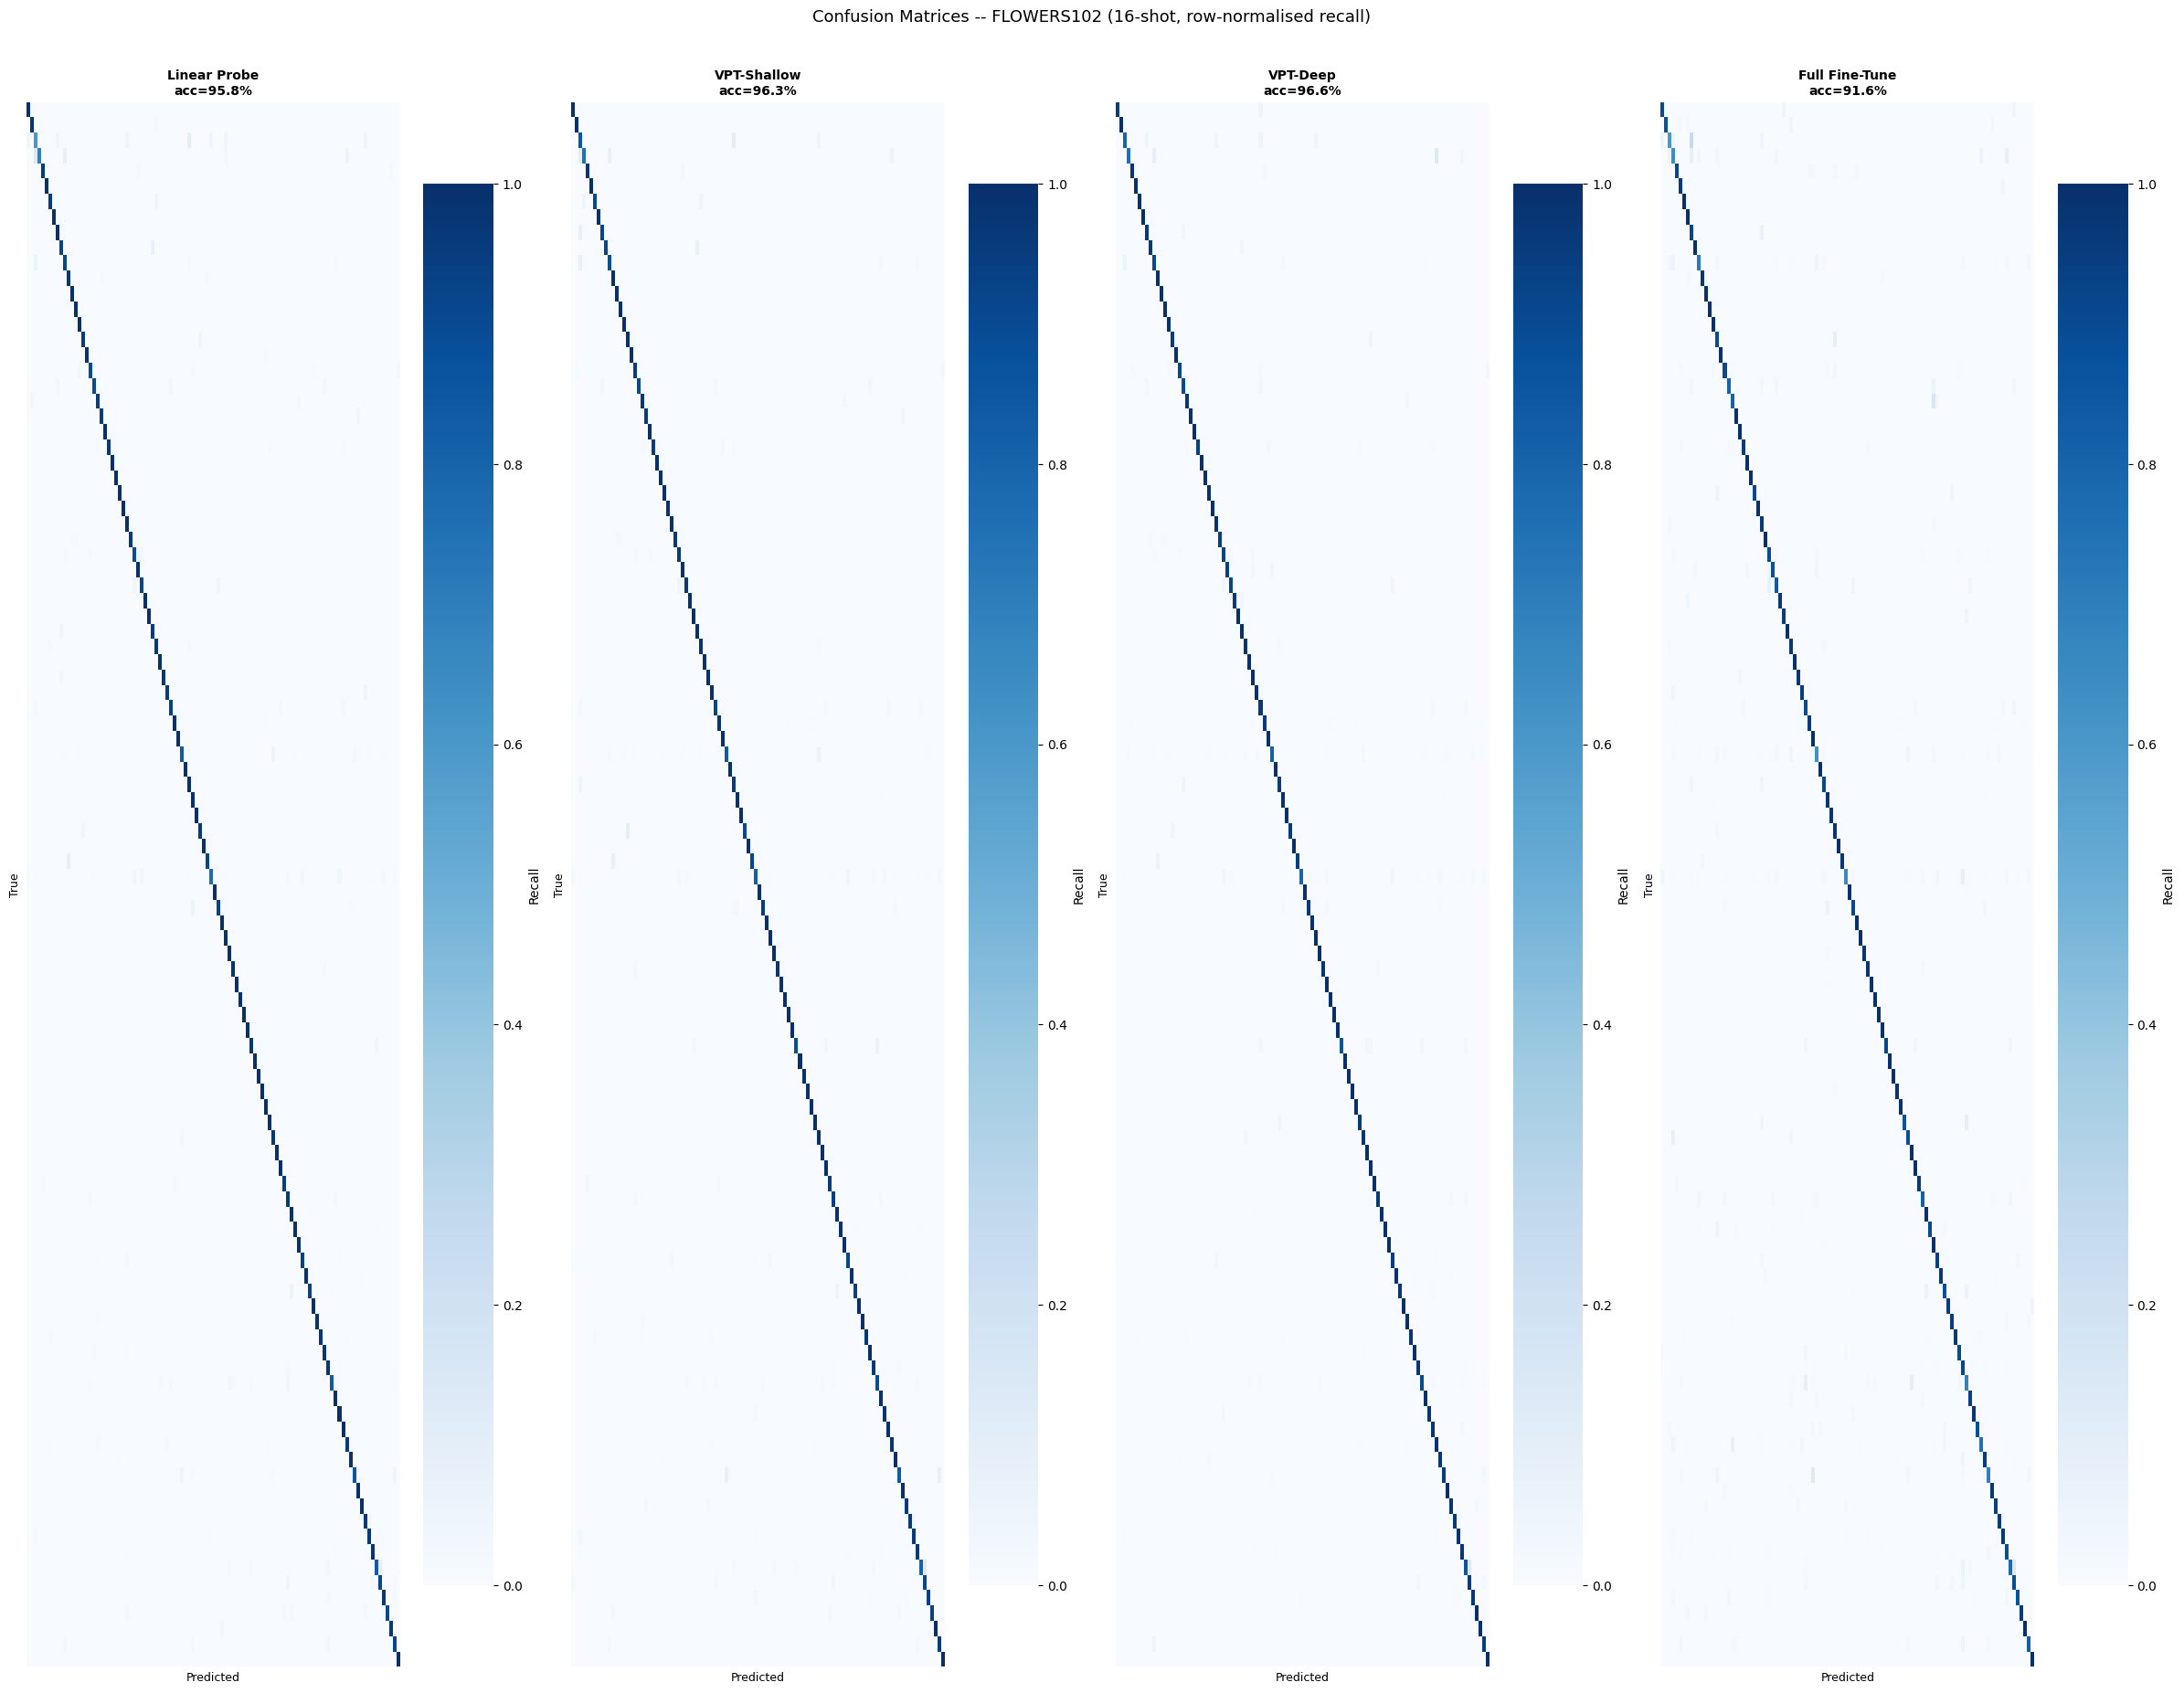

Saved confusion_matrix_flowers102_16shot.pdf

=== Per-class accuracy (mean over classes, 16-shot) ===
                           mean    std    min     max
dataset    method                                    
dtd        full_finetune  69.73  15.74  35.00   92.50
           linear_probe   70.21  18.09  32.50   97.50
           vpt_deep       73.46  17.47  22.50   95.00
           vpt_shallow    70.85  16.99  25.00   97.50
eurosat    full_finetune  90.91   5.46  82.57   98.22
           linear_probe   80.56  10.73  61.95   92.62
           vpt_deep       92.93   5.40  82.54   98.46
           vpt_shallow    88.11   7.37  74.64   96.23
flowers102 full_finetune  92.69   9.33  60.00  100.00
           linear_probe   96.21   6.35  60.00  100.00
           vpt_deep       96.98   4.83  75.00  100.00
           vpt_shallow    96.67   5.05  75.00  100.00


In [ ]:
print(
    f"Detailed Metrics at {16}-shot "
    f"(per-class accuracy + confusion matrices)"
)

EVAL_SHOT      = 16
detailed_rows: List[Dict] = []

for ds_name in DATASETS:
    _train_full, _val_full, _n_cls, _class_names = DATASET_CACHE[ds_name]
    _val_ldr = DataLoader(
        _val_full, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True
    )
    _n_cols  = len(METHODS)
    _fig_cm, _axes_cm = plt.subplots(
        1, _n_cols,
        figsize=(6 * _n_cols, max(5, _n_cls * 0.15 + 3)),
    )
    if _n_cols == 1:
        _axes_cm = [_axes_cm]

    for _ax_cm, method in zip(_axes_cm, METHODS):
        n_prompts  = best_prompt_config.get((method, EVAL_SHOT), DEFAULT_PROMPT_TOKENS)
        model      = build_model(method, _n_cls, n_prompts=n_prompts)
        lr, epochs = get_lr_and_epochs(method)

        _train_sub = few_shot_subset(_train_full, EVAL_SHOT)
        _train_ldr = DataLoader(
            _train_sub,
            batch_size=min(BATCH_SIZE, len(_train_sub)),
            shuffle=True, num_workers=2, pin_memory=True,
        )
        _optimizer = torch.optim.AdamW(
            model.trainable_params(), lr=lr, weight_decay=WD
        )
        _scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            _optimizer, T_max=epochs
        )
        _scaler = torch.cuda.amp.GradScaler()
        for epoch in range(epochs):
            train_one_epoch(model, _train_ldr, _optimizer, _scaler)
            _scheduler.step()

        acc, preds, true_labels = evaluate_with_predictions(model, _val_ldr)

        # Print classification report
        print(f"\n{ds_name.upper()} | {method} | {EVAL_SHOT}-shot")
        print(
            classification_report(
                true_labels, preds,
                target_names=_class_names,
                zero_division=0,
            )
        )

        #  Collect per-class accuracy
        for cls_idx, cls_name in enumerate(_class_names):
            _mask = true_labels == cls_idx
            if _mask.sum() == 0:
                continue
            cls_acc = float((preds[_mask] == cls_idx).mean())
            detailed_rows.append({
                "dataset":   ds_name,
                "method":    method,
                "n_shots":   EVAL_SHOT,
                "class_idx": cls_idx,
                "class":     cls_name,
                "accuracy":  round(cls_acc * 100, 2),
                "support":   int(_mask.sum()),
            })

        #  Confusion matrix (row-normalised = recall per class)
        cm      = confusion_matrix(true_labels, preds)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        _annot  = _n_cls <= 20
        sns.heatmap(
            cm_norm, ax=_ax_cm,
            cmap="Blues", vmin=0.0, vmax=1.0,
            annot=_annot, fmt=".2f" if _annot else "",
            xticklabels=_class_names if _n_cls <= 20 else [],
            yticklabels=_class_names if _n_cls <= 20 else [],
            cbar_kws={"label": "Recall"},
        )
        _ax_cm.set_title(
            f"{METHOD_LABELS[method]}\nacc={acc*100:.1f}%",
            fontsize=10, fontweight="bold",
        )
        _ax_cm.set_xlabel("Predicted", fontsize=9)
        _ax_cm.set_ylabel("True", fontsize=9)
        if _n_cls <= 20:
            _ax_cm.set_xticklabels(
                _ax_cm.get_xticklabels(), rotation=45, ha="right", fontsize=7
            )
            _ax_cm.set_yticklabels(
                _ax_cm.get_yticklabels(), rotation=0, fontsize=7
            )

        del model
        torch.cuda.empty_cache()

    _fig_cm.suptitle(
        f"Confusion Matrices -- {ds_name.upper()} "
        f"({EVAL_SHOT}-shot, row-normalised recall)",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    _cm_path = f"confusion_matrix_{ds_name}_{EVAL_SHOT}shot.pdf"
    plt.savefig(_cm_path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved {_cm_path}")

# Save per-class accuracy table
per_class_df = pd.DataFrame(detailed_rows)
per_class_df.to_csv("per_class_accuracy.csv", index=False)

print("\n=== Per-class accuracy (mean over classes, 16-shot) ===")
_summary_pc = (
    per_class_df.groupby(["dataset", "method"])["accuracy"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)
print(_summary_pc.to_string())

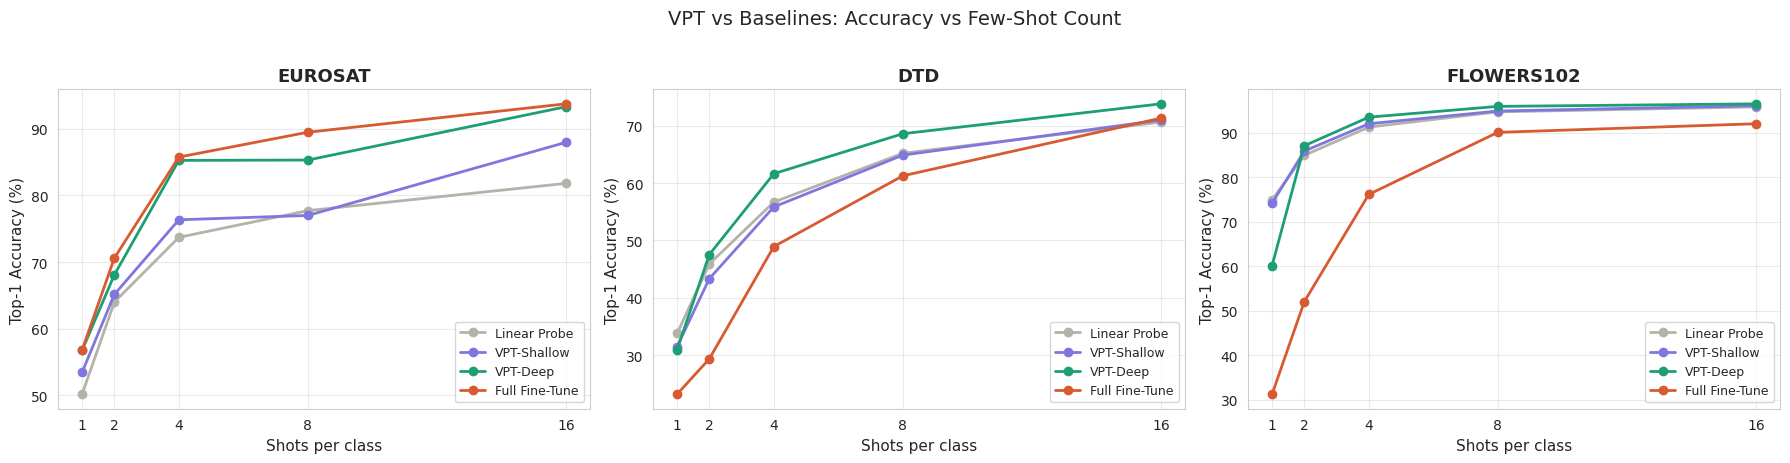

Saved accuracy_vs_shots.pdf


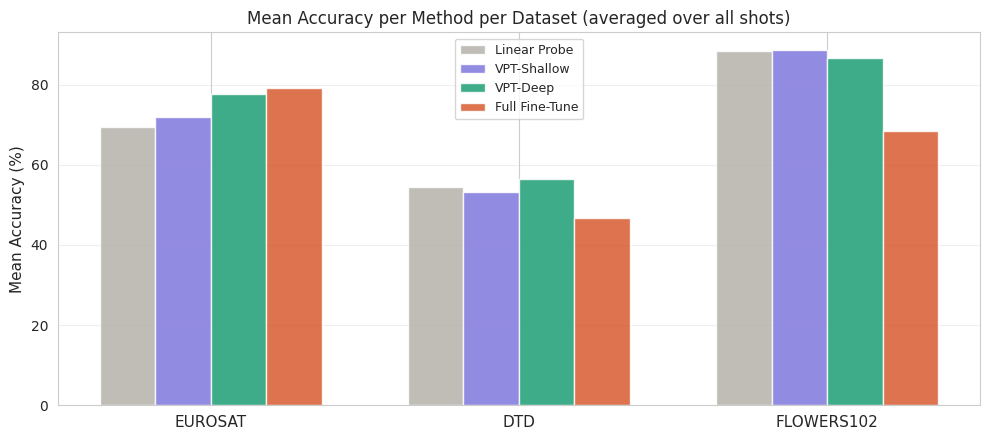

Saved mean_accuracy_by_dataset.pdf


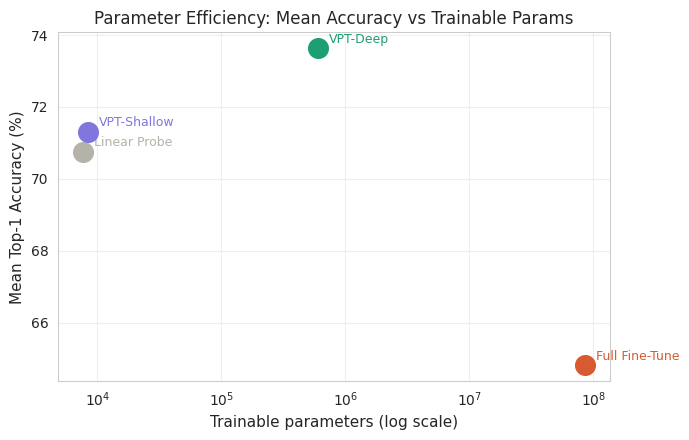

Saved parameter_efficiency.pdf


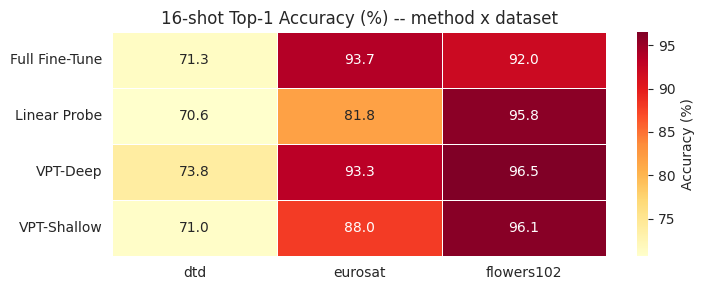

Saved heatmap_16shot.pdf


In [ ]:
sns.set_style("whitegrid")

#  11a: Accuracy vs shots, one subplot per dataset
fig, axes = plt.subplots(
    1, len(DATASETS), figsize=(6 * len(DATASETS), 4.5), sharey=False
)
if len(DATASETS) == 1:
    axes = [axes]
for ax, ds_name in zip(axes, DATASETS):
    _sub = df[df.dataset == ds_name]
    for method in METHODS:
        _m = _sub[_sub.method == method].sort_values("n_shots")
        ax.plot(
            _m.n_shots, _m.accuracy,
            marker="o", linewidth=2,
            label=METHOD_LABELS[method],
            color=COLORS[method],
        )
    ax.set_title(ds_name.upper(), fontsize=13, fontweight="bold")
    ax.set_xlabel("Shots per class", fontsize=11)
    ax.set_ylabel("Top-1 Accuracy (%)", fontsize=11)
    ax.set_xticks(SHOT_COUNTS)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)
fig.suptitle(
    "VPT vs Baselines: Accuracy vs Few-Shot Count",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.savefig("accuracy_vs_shots.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved accuracy_vs_shots.pdf")

# 11b: Mean accuracy per dataset, grouped bar chart
_mean_ds = (
    df.groupby(["dataset", "method"])["accuracy"].mean().reset_index()
)
fig, ax = plt.subplots(figsize=(10, 4.5))
_x      = np.arange(len(DATASETS))
_width  = 0.18
_offset = -(len(METHODS) - 1) / 2
for i, method in enumerate(METHODS):
    _vals = [
        _mean_ds.loc[
            (_mean_ds.dataset == ds) & (_mean_ds.method == method),
            "accuracy",
        ].values[0]
        for ds in DATASETS
    ]
    ax.bar(
        _x + (_offset + i) * _width, _vals, _width,
        label=METHOD_LABELS[method],
        color=COLORS[method], alpha=0.85,
    )
ax.set_xticks(_x)
ax.set_xticklabels([d.upper() for d in DATASETS], fontsize=11)
ax.set_ylabel("Mean Accuracy (%)", fontsize=11)
ax.set_title(
    "Mean Accuracy per Method per Dataset (averaged over all shots)",
    fontsize=12,
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("mean_accuracy_by_dataset.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved mean_accuracy_by_dataset.pdf")

#  11c: Parameter efficiency scatter
_overall_mean = df.groupby("method")["accuracy"].mean()
fig, ax = plt.subplots(figsize=(7, 4.5))
for method in METHODS:
    ax.scatter(
        param_counts[method], _overall_mean[method],
        s=200, color=COLORS[method],
        label=METHOD_LABELS[method], zorder=5,
    )
    ax.annotate(
        METHOD_LABELS[method],
        xy=(param_counts[method], _overall_mean[method]),
        xytext=(8, 4), textcoords="offset points",
        fontsize=9, color=COLORS[method],
    )
ax.set_xscale("log")
ax.set_xlabel("Trainable parameters (log scale)", fontsize=11)
ax.set_ylabel("Mean Top-1 Accuracy (%)", fontsize=11)
ax.set_title(
    "Parameter Efficiency: Mean Accuracy vs Trainable Params",
    fontsize=12,
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("parameter_efficiency.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved parameter_efficiency.pdf")

#  11d: 16-shot heatmap, method x dataset
_shot16 = (
    df[df.n_shots == 16]
    .pivot(index="method", columns="dataset", values="accuracy")
    .rename(index=METHOD_LABELS)
)
fig, ax = plt.subplots(figsize=(max(4, len(DATASETS) * 2.5), 3))
sns.heatmap(
    _shot16, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Accuracy (%)"},
)
ax.set_title(
    "16-shot Top-1 Accuracy (%) -- method x dataset",
    fontsize=12,
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("heatmap_16shot.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved heatmap_16shot.pdf")

In [ ]:
_ft_params = param_counts.get("full_finetune", 1)
summary = df.groupby("method")["accuracy"].mean().reset_index()
summary.columns = ["method", "mean_acc_%"]
summary["trainable_params"] = summary["method"].map(param_counts)
summary["pct_of_full_ft"]   = (
    summary["trainable_params"] / _ft_params * 100
).round(3)
summary["method_label"] = summary["method"].map(METHOD_LABELS)
summary = summary.sort_values("mean_acc_%", ascending=False).reset_index(drop=True)
print(
    summary[
        ["method_label", "mean_acc_%", "trainable_params", "pct_of_full_ft"]
    ].to_string(index=False)
)

print("\n=== Per-dataset mean accuracy (%) -- all shots ===")
_pivot_all = (
    df.groupby(["dataset", "method"])["accuracy"]
    .mean()
    .unstack()
    .rename(columns=METHOD_LABELS)
)
print(_pivot_all.round(2).to_string())

print("\n=== Per-dataset accuracy (%) -- 16-shot only ===")
_pivot16 = (
    df[df.n_shots == 16]
    .groupby(["dataset", "method"])["accuracy"]
    .mean()
    .unstack()
    .rename(columns=METHOD_LABELS)
)
print(_pivot16.round(2).to_string())

print("\n=== Mean accuracy across all datasets (%) ===")
_mean_all = df.groupby("method")["accuracy"].mean().rename(METHOD_LABELS)
print(_mean_all.round(2).to_string())

print("\nAll outputs saved:")
_output_files = [
    "phase1_ablation.csv",
    "phase1_prompt_length_heatmap.pdf",
    "phase1_prompt_length_curves.pdf",
    "phase2_results.csv",
    "accuracy_vs_shots.pdf",
    "mean_accuracy_by_dataset.pdf",
    "parameter_efficiency.pdf",
    "heatmap_16shot.pdf",
    "per_class_accuracy.csv",
] + [
    f"confusion_matrix_{ds}_{EVAL_SHOT}shot.pdf"
    for ds in DATASETS
]
for f in _output_files:
    print(f"  {f}")


  method_label  mean_acc_%  trainable_params  pct_of_full_ft
      VPT-Deep   73.636667            597514           0.696
   VPT-Shallow   71.306667              8458           0.010
  Linear Probe   70.756667              7690           0.009
Full Fine-Tune   64.812000          85807114         100.000

=== Per-dataset mean accuracy (%) -- all shots ===
method      Full Fine-Tune  Linear Probe  VPT-Deep  VPT-Shallow
dataset                                                        
dtd                  46.82         54.45     56.52        53.32
eurosat              79.28         69.49     77.74        71.98
flowers102           68.34         88.34     86.64        88.62

=== Per-dataset accuracy (%) -- 16-shot only ===
method      Full Fine-Tune  Linear Probe  VPT-Deep  VPT-Shallow
dataset                                                        
dtd                  71.33         70.64     73.83        71.01
eurosat              93.74         81.81     93.30        87.96
flowers102       